# 🚀 AirVLC v2 — Notebook Multitarget en Colab

Notebook autocontenido para entrenar **3 arquitecturas Keras** que
predicen simultáneamente **PM2.5, NO₂ y O₃** a 1 hora vista.

> **Origen**: Sprint 2 v2 (`docs/v2AirVLCdocs/sprint2/`).
> v1 sigue intacta, esto convive con `notebooks/05_Colab_LSTM_Model.ipynb`.

## Pipeline en Colab
1. Setup (drive, GPU check).
2. Carga de `master_dataset_colab_v2.csv` + `scaler_v2.pkl`.
3. Split temporal cronológico **por estación** (80/10/10).
4. Construcción de secuencias `(N, 24, 44)` y `y = (N, 3)`.
5. Entrenamiento de las 3 arquitecturas.
6. Métricas por target en µg/m³ reales (MAE/RMSE/R²).
7. (Opcional) Re-entreno del ganador con loss asimétrica para picos.
8. Export del ganador a `models/modelo_11_v2_Multitarget/`.

> **Antes de correr**: sube `master_dataset_colab_v2.csv` y
> `scaler_v2.pkl` a tu Drive en
> `MyDrive/AirVLC_v2/` (o ajusta `BASE_DRIVE` abajo).


### Setup

In [1]:
import os, json, time, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TF version:', tf.__version__)
print('GPU disponible:', tf.config.list_physical_devices('GPU'))

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)


TF version: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DRIVE = '/content/drive/MyDrive/AirVLC_v2'
DATA_PATH = os.path.join(BASE_DRIVE, 'master_dataset_colab_v2.csv')
SCALER_PATH = os.path.join(BASE_DRIVE, 'scaler_v2.pkl')

OUTPUT_DIR = os.path.join(BASE_DRIVE, 'modelo_11_v2_Multitarget')
os.makedirs(OUTPUT_DIR, exist_ok=True)

assert os.path.exists(DATA_PATH), f'Sube primero master_dataset_colab_v2.csv a {BASE_DRIVE}'
assert os.path.exists(SCALER_PATH), f'Sube primero scaler_v2.pkl a {BASE_DRIVE}'
print('✅ Rutas OK')
print('  CSV:', DATA_PATH)
print('  Scaler:', SCALER_PATH)
print('  Salida:', OUTPUT_DIR)


Mounted at /content/drive
✅ Rutas OK
  CSV: /content/drive/MyDrive/AirVLC_v2/master_dataset_colab_v2.csv
  Scaler: /content/drive/MyDrive/AirVLC_v2/scaler_v2.pkl
  Salida: /content/drive/MyDrive/AirVLC_v2/modelo_11_v2_Multitarget


In [3]:
TARGETS = ['pm25', 'no2', 'o3']
NON_FEATURE_COLS = ['station_name']
SEQ_LEN = 24

def load_v2_dataset(path):
    df = pd.read_csv(path, parse_dates=['fecha'])
    df = df.sort_values(['station_name', 'fecha']).reset_index(drop=True)
    df = df.set_index('fecha')
    return df

def list_feature_columns(df):
    return [c for c in df.columns if c not in NON_FEATURE_COLS]

def chronological_split_by_station(df, train_frac=0.8, val_frac=0.1):
    train, val, test = [], [], []
    for _, group in df.groupby('station_name', sort=False):
        n = len(group)
        n_train = int(n * train_frac)
        n_val = int(n * val_frac)
        train.append(group.iloc[:n_train])
        val.append(group.iloc[n_train:n_train+n_val])
        test.append(group.iloc[n_train+n_val:])
    return (pd.concat(train), pd.concat(val), pd.concat(test))

def build_sequences_multitarget(df, feature_cols, scaler, seq_len=SEQ_LEN,
                                targets=None, group_col='station_name',
                                max_gap_hours=1.0):
    if targets is None:
        targets = TARGETS
    df = df.copy()
    df[feature_cols] = scaler.transform(df[feature_cols])
    target_idx = [feature_cols.index(t) for t in targets]
    xs, ys = [], []
    # Trabajamos con timestamps en nanosegundos (int64) para ser
    # robustos a la unidad temporal del DatetimeIndex, que cambia entre
    # versiones de pandas+numpy (us / ns / ms) y entre local y Colab.
    gap_threshold_ns = np.int64(int(max_gap_hours * 3_600 * 1_000_000_000))
    for _, group in df.groupby(group_col, sort=False):
        if len(group) <= seq_len:
            continue
        feat = group[feature_cols].to_numpy(dtype=np.float32)
        ts_ns = group.index.values.astype('datetime64[ns]').astype(np.int64)
        for i in range(len(group) - seq_len):
            j = i + seq_len
            diffs_ns = np.diff(ts_ns[i:j+1])
            if (diffs_ns > gap_threshold_ns).any():
                continue
            xs.append(feat[i:j])
            ys.append(feat[j, target_idx])
    if not xs:
        return (np.empty((0, seq_len, len(feature_cols)), dtype=np.float32),
                np.empty((0, len(targets)), dtype=np.float32))
    return np.stack(xs), np.stack(ys)

def inverse_transform_targets(y_scaled, scaler, feature_cols, targets=None):
    if targets is None:
        targets = TARGETS
    if y_scaled.ndim == 1:
        y_scaled = y_scaled.reshape(-1, len(targets))
    n = y_scaled.shape[0]
    dummy = np.zeros((n, len(feature_cols)), dtype=np.float32)
    target_idx = [feature_cols.index(t) for t in targets]
    for j, idx in enumerate(target_idx):
        dummy[:, idx] = y_scaled[:, j]
    inv = scaler.inverse_transform(dummy)
    return inv[:, target_idx]


## 1. Carga de dataset y scaler

In [4]:
df = load_v2_dataset(DATA_PATH)
print('Shape:', df.shape)
print('Rango:', df.index.min(), '→', df.index.max())
print('Estaciones:', sorted(df['station_name'].unique()))

with open(SCALER_PATH, 'rb') as fh:
    artifact = pickle.load(fh)
scaler = artifact['scaler']
feature_cols = artifact['feature_cols']
print(f'Features ({len(feature_cols)}):', feature_cols[:6], '...')


Shape: (194198, 45)
Rango: 2016-01-02 00:00:00 → 2021-12-31 23:00:00
Estaciones: ['Francia', 'Molí del Sol', 'Pista de Silla', 'Puerto Moll Trans. Ponent', 'Puerto Valencia', 'Puerto llit antic Túria', 'Universidad Politécnica']
Features (44): ['pm25', 'no2', 'o3', 'temperatura', 'velocidad_viento', 'precipitacion'] ...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 2. Split temporal por estación + secuencias multitarget

* Train: 80% de cada estación (orden cronológico).
* Val: 10% medio.
* Test: 10% final (lo más reciente — eval realista).
* Las ventanas que crucen huecos de más de 1 hora se descartan
  automáticamente para evitar entrenar con saltos artificiales.

In [5]:
train_df, val_df, test_df = chronological_split_by_station(df)
print(f'Train rows: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}')

X_train, y_train = build_sequences_multitarget(train_df, feature_cols, scaler)
X_val,   y_val   = build_sequences_multitarget(val_df,   feature_cols, scaler)
X_test,  y_test  = build_sequences_multitarget(test_df,  feature_cols, scaler)

print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val:  ', X_val.shape,   'y_val:  ', y_val.shape)
print('X_test: ', X_test.shape,  'y_test: ', y_test.shape)

# Hard-fail si el sequencing devuelve 0 ventanas (suele indicar que el
# CSV tiene timestamps repetidos / mal formados; ver `errores_modelo.md`).
assert X_train.shape[0] > 0, (
    'Sequencing devolvió 0 ventanas en train. '
    'Revisa que master_dataset_colab_v2.csv tenga timestamps horarios '
    'reales (cada fila con su hora) y que `df.index` tenga >5k '
    'valores únicos. Si no, regenera el CSV con '
    'src/ml/prepare_colab_dataset_v2.py y vuelve a subirlo.'
)

SEQ_LEN, N_FEATURES = X_train.shape[1], X_train.shape[2]
N_TARGETS = y_train.shape[1]


Train rows: 155,356  Val: 19,416  Test: 19,426
X_train: (152308, 24, 44) y_train: (152308, 3)
X_val:   (18796, 24, 44) y_val:   (18796, 3)
X_test:  (18949, 24, 44) y_test:  (18949, 3)


## 3. Función de evaluación por target

In [6]:
def evaluate_multitarget(model, X, y, scaler, feature_cols, name='model'):
    y_pred_scaled = model.predict(X, verbose=0)
    y_pred_real = inverse_transform_targets(y_pred_scaled, scaler, feature_cols)
    y_true_real = inverse_transform_targets(y,            scaler, feature_cols)
    rows = []
    for j, t in enumerate(TARGETS):
        mae  = mean_absolute_error(y_true_real[:, j], y_pred_real[:, j])
        rmse = np.sqrt(mean_squared_error(y_true_real[:, j], y_pred_real[:, j]))
        r2   = r2_score(y_true_real[:, j], y_pred_real[:, j])
        rows.append({'arch': name, 'target': t,
                     'mae': mae, 'rmse': rmse, 'r2': r2})
    df_r = pd.DataFrame(rows)
    print(df_r.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
    return df_r, y_pred_real, y_true_real


## 4. Arquitectura 1 — LSTM_Attention_Multi (Bahdanau)

LSTM 2 capas → Attention de Bahdanau (dot-product simplificado) →
Dense(32) → **Dense(3)**. Heredada del notebook 07 v1, adaptada a 3
salidas.

In [7]:
class BahdanauAttention(layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(units)
        self.U = layers.Dense(units)
        self.V = layers.Dense(1)
    def call(self, encoder_outputs):
        score = self.V(tf.nn.tanh(self.W(encoder_outputs) + self.U(encoder_outputs)))
        weights = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(weights * encoder_outputs, axis=1)
        return context

def build_lstm_attention_multi(seq_len, n_features, n_targets, lr=1e-3, dropout=0.2):
    inp = layers.Input(shape=(seq_len, n_features))
    x = layers.LSTM(128, return_sequences=True)(inp)
    x = layers.Dropout(dropout)(x)
    x = layers.LSTM(64, return_sequences=True)(x)
    x = layers.Dropout(dropout)(x)
    x = BahdanauAttention(64)(x)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(n_targets, name='output')(x)
    m = Model(inp, out, name='LSTM_Attention_Multi')
    m.compile(optimizer=keras.optimizers.Adam(lr), loss='mse', metrics=['mae'])
    return m

model_lstm_attn = build_lstm_attention_multi(SEQ_LEN, N_FEATURES, N_TARGETS)
model_lstm_attn.summary()


Model: "LSTM_Attention_Multi"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 44)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 24, 128)        │        88,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bahdanau_attention              │ (None, 64)             │         8,385 │
│ (BahdanauAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,548 (580.27 KB)

 Trainable params: 148,548 (580.27 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Arquitectura 2 — CNN_LSTM_Attention_Multi

Conv1D extrae patrones locales (picos de tráfico, ráfagas) → LSTM
modela la dinámica → Attention pondera timesteps relevantes → Dense(3).

In [8]:
def build_cnn_lstm_attention_multi(seq_len, n_features, n_targets, lr=1e-3, dropout=0.2):
    inp = layers.Input(shape=(seq_len, n_features))
    x = layers.Conv1D(64, kernel_size=3, padding='causal', activation='relu')(inp)
    x = layers.Conv1D(64, kernel_size=3, padding='causal', activation='relu')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.LSTM(96, return_sequences=True)(x)
    x = layers.Dropout(dropout)(x)
    x = BahdanauAttention(64)(x)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(n_targets, name='output')(x)
    m = Model(inp, out, name='CNN_LSTM_Attention_Multi')
    m.compile(optimizer=keras.optimizers.Adam(lr), loss='mse', metrics=['mae'])
    return m

model_cnn_lstm = build_cnn_lstm_attention_multi(SEQ_LEN, N_FEATURES, N_TARGETS)
model_cnn_lstm.summary()


Model: "CNN_LSTM_Attention_Multi"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 24, 44)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 24, 64)         │         8,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 24, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 12, 96)         │        61,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bahdanau_attention_1            │ (None, 96)             │        12,481 │
│ (BahdanauAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,372 (384.27 KB)

 Trainable params: 98,372 (384.27 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Arquitectura 3 — Transformer_Encoder_Multi

MultiHeadAttention nativa de Keras + LayerNorm + FFN + Global Average
Pooling → Dense(3). Mantiene el sabor "Transformer" sin la complicación
de PyTorch / TFT.

In [9]:
def transformer_block(inputs, num_heads, key_dim, ff_dim, dropout=0.2):
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim,
                                     dropout=dropout)(inputs, inputs)
    x = layers.LayerNormalization(epsilon=1e-6)(inputs + attn)
    ff = layers.Dense(ff_dim, activation='relu')(x)
    ff = layers.Dense(inputs.shape[-1])(ff)
    return layers.LayerNormalization(epsilon=1e-6)(x + ff)

def build_transformer_encoder_multi(seq_len, n_features, n_targets,
                                    num_heads=4, key_dim=32, ff_dim=128,
                                    n_blocks=2, lr=1e-3, dropout=0.2):
    inp = layers.Input(shape=(seq_len, n_features))
    x = layers.Dense(64)(inp)
    for _ in range(n_blocks):
        x = transformer_block(x, num_heads, key_dim, ff_dim, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(n_targets, name='output')(x)
    m = Model(inp, out, name='Transformer_Encoder_Multi')
    m.compile(optimizer=keras.optimizers.Adam(lr), loss='mse', metrics=['mae'])
    return m

model_transformer = build_transformer_encoder_multi(SEQ_LEN, N_FEATURES, N_TARGETS)
model_transformer.summary()


Model: "Transformer_Encoder_Multi"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 24, 44)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 24, 64)    │      2,880 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 64)    │     33,216 │ dense_8[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 64)    │          0 │ dense_8[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 24, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 24, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 24, 64)    │      8,256 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 24, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 64)    │     33,216 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 24, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 24, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 24, 64)    │      8,256 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 24, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 64)        │          0 │ dense_13[0][0]  

 Total params: 107,331 (419.26 KB)

 Trainable params: 107,331 (419.26 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Entrenamiento comparado (las 3 arquitecturas)

EarlyStopping monitor='val_loss', patience=8.
ReduceLROnPlateau factor=0.5, patience=4.

In [10]:
EPOCHS = 60
BATCH = 128

def fit_model(model, name):
    print('\n' + '='*70)
    print(f'🚀 Entrenando {name}')
    print('='*70)
    cb = [
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6),
    ]
    t0 = time.time()
    hist = model.fit(X_train, y_train,
                     validation_data=(X_val, y_val),
                     epochs=EPOCHS, batch_size=BATCH,
                     callbacks=cb, verbose=1)
    secs = time.time() - t0
    print(f'⏱ {name}: {secs:.1f}s, best epoch={int(np.argmin(hist.history["val_loss"]))+1}')
    return hist, secs

hist_lstm, t_lstm = fit_model(model_lstm_attn,    'LSTM_Attention_Multi')
hist_cnn,  t_cnn  = fit_model(model_cnn_lstm,     'CNN_LSTM_Attention_Multi')
hist_trf,  t_trf  = fit_model(model_transformer,  'Transformer_Encoder_Multi')



🚀 Entrenando LSTM_Attention_Multi
Epoch 1/60
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - loss: 0.0136 - mae: 0.0838 - val_loss: 0.0046 - val_mae: 0.0470 - learning_rate: 0.0010
Epoch 2/60
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.0061 - mae: 0.0542 - val_loss: 0.0038 - val_mae: 0.0412 - learning_rate: 0.0010
Epoch 3/60
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - loss: 0.0054 - mae: 0.0500 - val_loss: 0.0036 - val_mae: 0.0398 - learning_rate: 0.0010
Epoch 4/60
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.0051 - mae: 0.0483 - val_loss: 0.0035 - val_mae: 0.0377 - learning_rate: 0.0010
Epoch 5/60
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.0049 - mae: 0.0472 - val_loss: 0.0034 - val_mae: 0.0381 - learning_rate: 0.0010
Epoch 6/60
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.0048 - mae: 0.0467 - val_loss: 0.0034 - val_mae: 0.0372 - learning_rate: 0.0010
Epoch 7/60
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.0047 - mae: 0.0461 - va

## 8. Evaluación por target (µg/m³ reales)

In [11]:
def eval_arch(model, name, t_train):
    df_r, y_pred_real, y_true_real = evaluate_multitarget(
        model, X_test, y_test, scaler, feature_cols, name=name)
    df_r['n_params'] = model.count_params()
    df_r['training_time_sec'] = round(t_train, 1)
    return df_r, y_pred_real, y_true_real

r1, p1, _ = eval_arch(model_lstm_attn,    'LSTM_Attention_Multi',     t_lstm)
r2, p2, _ = eval_arch(model_cnn_lstm,     'CNN_LSTM_Attention_Multi', t_cnn)
r3, p3, _ = eval_arch(model_transformer,  'Transformer_Encoder_Multi', t_trf)

results = pd.concat([r1, r2, r3], ignore_index=True)
results.to_csv(os.path.join(OUTPUT_DIR, 'day11_v2_results.csv'), index=False)

# Score agregado (promedio de R² entre los 3 targets, mayor = mejor)
ranking = (results.groupby('arch')['r2'].mean()
           .sort_values(ascending=False).reset_index(name='avg_r2'))
print('\n🏆 Ranking por R² medio entre los 3 targets:')
print(ranking.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

best_arch = ranking.iloc[0]['arch']
print(f'\n🥇 Ganador: {best_arch}')


                arch target    mae   rmse     r2
LSTM_Attention_Multi   pm25 1.5681 2.8279 0.8571
LSTM_Attention_Multi    no2 3.8648 5.9141 0.8397
LSTM_Attention_Multi     o3 6.2557 8.8754 0.8861
                    arch target    mae   rmse     r2
CNN_LSTM_Attention_Multi   pm25 1.6658 2.9112 0.8486
CNN_LSTM_Attention_Multi    no2 4.0004 6.0163 0.8341
CNN_LSTM_Attention_Multi     o3 6.5025 9.0430 0.8818
                     arch target    mae   rmse     r2
Transformer_Encoder_Multi   pm25 1.8004 2.9814 0.8412
Transformer_Encoder_Multi    no2 4.3483 6.2119 0.8231
Transformer_Encoder_Multi     o3 6.9516 9.3366 0.8740

🏆 Ranking por R² medio entre los 3 targets:
                     arch  avg_r2
     LSTM_Attention_Multi  0.8610
 CNN_LSTM_Attention_Multi  0.8548
Transformer_Encoder_Multi  0.8461

🥇 Ganador: LSTM_Attention_Multi


## 9. Curvas de pérdida y predicción vs realidad por target

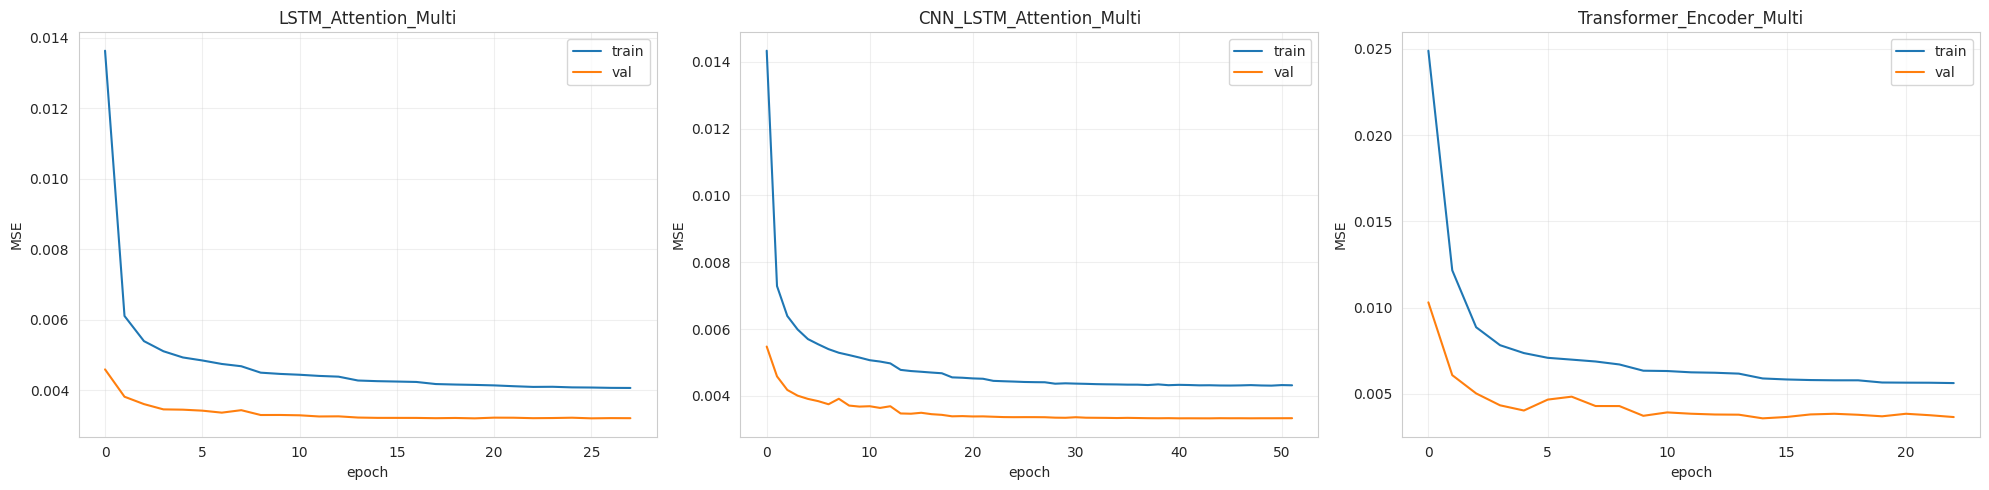

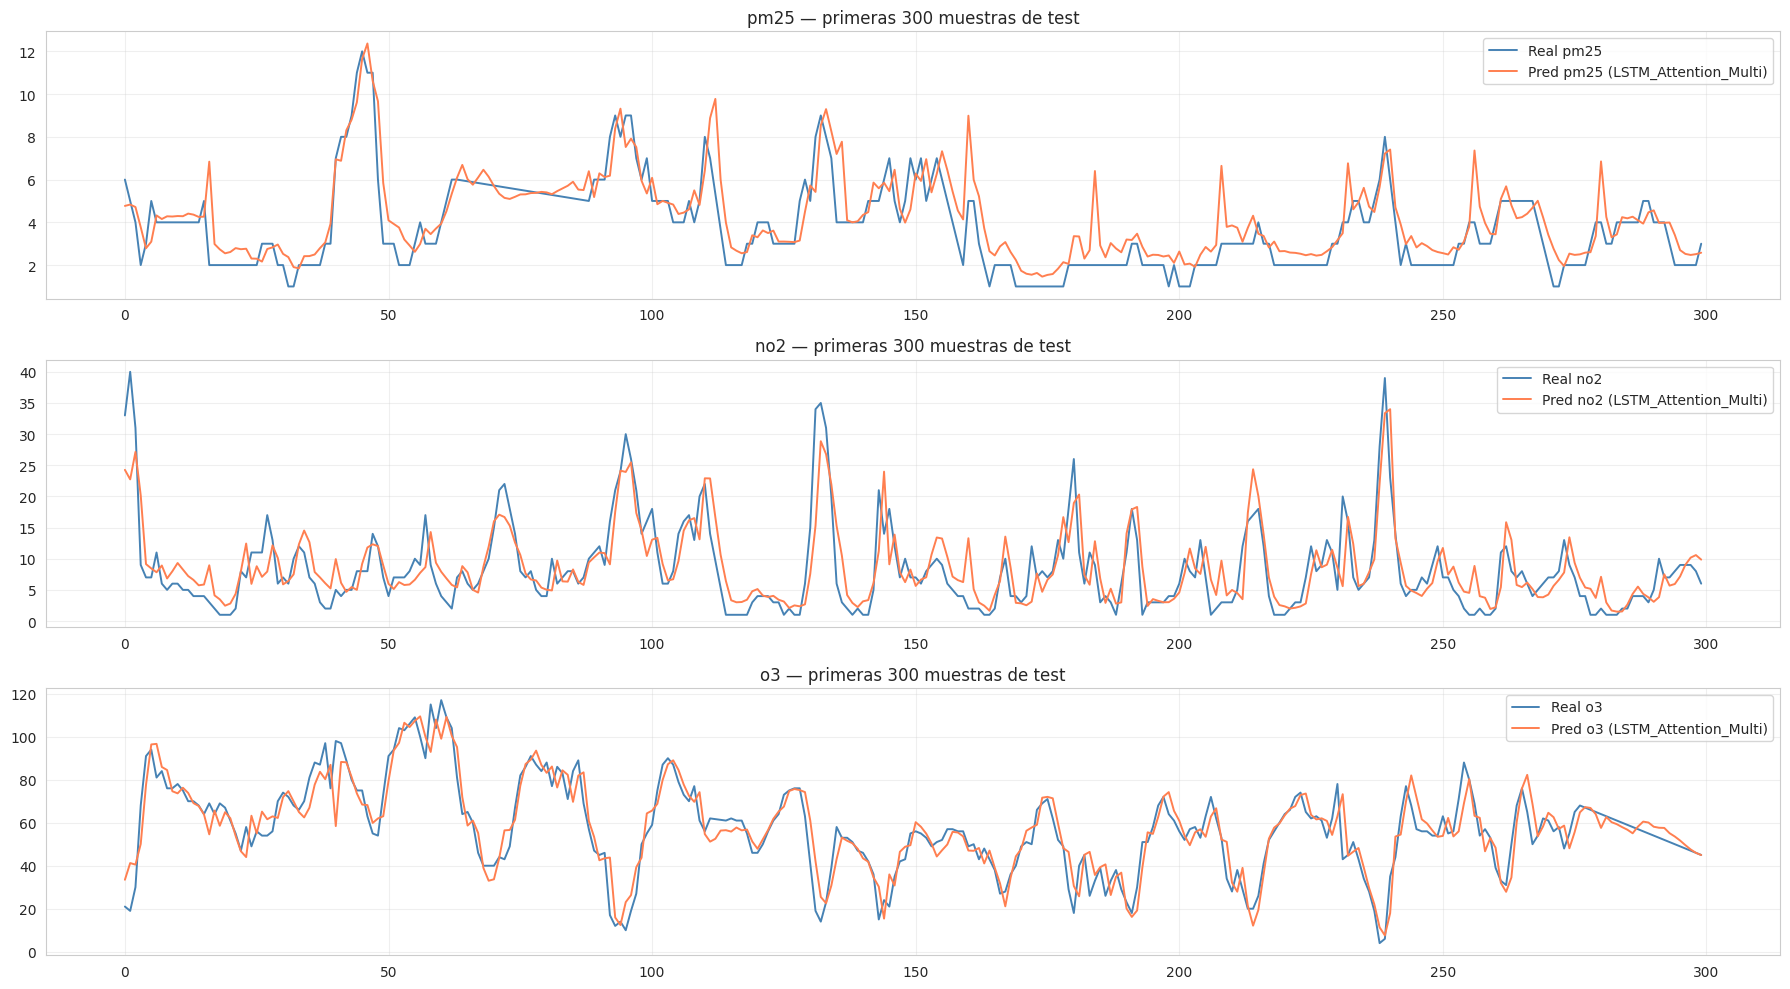

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, (name, h) in zip(axes, [
        ('LSTM_Attention_Multi', hist_lstm),
        ('CNN_LSTM_Attention_Multi', hist_cnn),
        ('Transformer_Encoder_Multi', hist_trf)]):
    ax.plot(h.history['loss'], label='train')
    ax.plot(h.history['val_loss'], label='val')
    ax.set_title(name)
    ax.set_xlabel('epoch'); ax.set_ylabel('MSE'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Predicciones vs reales del ganador (primeras 300 filas de test)
preds = {'LSTM_Attention_Multi': p1, 'CNN_LSTM_Attention_Multi': p2,
         'Transformer_Encoder_Multi': p3}
y_best = preds[best_arch]
y_real = inverse_transform_targets(y_test, scaler, feature_cols)

fig, axes = plt.subplots(3, 1, figsize=(18, 10))
for j, (ax, t) in enumerate(zip(axes, TARGETS)):
    ax.plot(y_real[:300, j], label=f'Real {t}', linewidth=1.4, color='steelblue')
    ax.plot(y_best[:300, j], label=f'Pred {t} ({best_arch})', linewidth=1.4, color='coral')
    ax.set_title(f'{t} — primeras 300 muestras de test'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 10. (Opcional) Re-entreno con loss asimétrica

Penaliza más infraestimar (predicción < realidad cuando hay pico) que
sobreestimar. Útil porque infraestimar un pico de O₃ o NO₂ es más
peligroso para salud que sobreestimar.

> Solo se entrena el ganador. Comparamos con su versión MSE.

In [13]:
def asymmetric_mse(alpha=2.0):
    def _loss(y_true, y_pred):
        err = y_true - y_pred
        # Penaliza más cuando se predice por debajo (err > 0)
        weight = tf.where(err > 0, alpha, 1.0)
        return tf.reduce_mean(weight * tf.square(err))
    return _loss

# Reconstruimos el ganador para entrenarlo desde 0 con la nueva loss.
builders = {
    'LSTM_Attention_Multi':       build_lstm_attention_multi,
    'CNN_LSTM_Attention_Multi':   build_cnn_lstm_attention_multi,
    'Transformer_Encoder_Multi':  build_transformer_encoder_multi,
}
model_asym = builders[best_arch](SEQ_LEN, N_FEATURES, N_TARGETS)
model_asym.compile(optimizer=keras.optimizers.Adam(1e-3),
                   loss=asymmetric_mse(alpha=2.0),
                   metrics=['mae'])

cb = [EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
      ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)]
hist_asym = model_asym.fit(X_train, y_train,
                           validation_data=(X_val, y_val),
                           epochs=EPOCHS, batch_size=BATCH,
                           callbacks=cb, verbose=1)

r_asym, p_asym, _ = eval_arch(model_asym,
                              f'{best_arch}_AsymLoss',
                              0.0)


Epoch 1/60
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 0.0202 - mae: 0.0898 - val_loss: 0.0066 - val_mae: 0.0519 - learning_rate: 0.0010
Epoch 2/60
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 0.0089 - mae: 0.0577 - val_loss: 0.0055 - val_mae: 0.0453 - learning_rate: 0.0010
Epoch 3/60
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.0079 - mae: 0.0531 - val_loss: 0.0052 - val_mae: 0.0428 - learning_rate: 0.0010
Epoch 4/60
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.0075 - mae: 0.0514 - val_loss: 0.0050 - val_mae: 0.0397 - learning_rate: 0.0010
Epoch 5/60
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.0072 - mae: 0.0503 - val_loss: 0.0049 - val_mae: 0.0397 - learning_rate: 0.0010
Epoch 6/60
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.0070 - mae: 0.0496 - val_loss: 0.0049 - val_mae: 0.0402 - learning_rate: 0.0010
Epoch 7/60
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.0069 - mae: 0.0491 - val_loss: 0.0048 - val_mae: 0.0382 - 

## 11. Export del ganador

Guarda en `models/modelo_11_v2_Multitarget/` (en tu Drive):
- `best_model_v2.keras` — modelo Keras del ganador (loss MSE).
- `best_model_v2_asym.keras` — versión con loss asimétrica (si la has corrido).
- `day11_v2_results.csv` — métricas comparadas por target.
- `training_history.json` — historiales de entrenamiento.

Tras descargarlos a `models/modelo_11_v2_Multitarget/` en local,
Sprint 3 (Flask v2) los cargará vía `feature_extractor_v2.py`.

In [14]:
best_model_obj = {
    'LSTM_Attention_Multi':       model_lstm_attn,
    'CNN_LSTM_Attention_Multi':   model_cnn_lstm,
    'Transformer_Encoder_Multi':  model_transformer,
}[best_arch]
best_path = os.path.join(OUTPUT_DIR, 'best_model_v2.keras')
best_model_obj.save(best_path)
print(f'💾 Ganador guardado: {best_path}')

try:
    asym_path = os.path.join(OUTPUT_DIR, 'best_model_v2_asym.keras')
    model_asym.save(asym_path)
    print(f'💾 Variante asimétrica guardada: {asym_path}')
except NameError:
    pass

with open(os.path.join(OUTPUT_DIR, 'training_history.json'), 'w') as fh:
    json.dump({
        'LSTM_Attention_Multi': {k: list(map(float, v))
                                 for k, v in hist_lstm.history.items()},
        'CNN_LSTM_Attention_Multi': {k: list(map(float, v))
                                     for k, v in hist_cnn.history.items()},
        'Transformer_Encoder_Multi': {k: list(map(float, v))
                                      for k, v in hist_trf.history.items()},
    }, fh, indent=2)

print('✅ Sprint 2 v2 listo. Resumen:')
print(results.pivot(index='arch', columns='target', values='r2')
       .round(4))


💾 Ganador guardado: /content/drive/MyDrive/AirVLC_v2/modelo_11_v2_Multitarget/best_model_v2.keras
💾 Variante asimétrica guardada: /content/drive/MyDrive/AirVLC_v2/modelo_11_v2_Multitarget/best_model_v2_asym.keras
✅ Sprint 2 v2 listo. Resumen:
target                        no2      o3    pm25
arch                                             
CNN_LSTM_Attention_Multi   0.8341  0.8818  0.8486
LSTM_Attention_Multi       0.8397  0.8861  0.8571
Transformer_Encoder_Multi  0.8231  0.8740  0.8412
